# THỰC HÀNH PHÂN TÍCH DỮ LIỆU LỚN VỚI APACHE SPARK VÀ PYSPARK

## Mục tiêu

- Hiểu vai trò của Apache Spark trong xử lý dữ liệu lớn;
- Làm việc với `SparkContext`, `SparkSession`;
- Sử dụng RDD, transformations và actions;
- Xử lý Pair RDD;
- Làm Word Count;
- Thao tác DataFrame;
- Truy vấn Spark SQL;
- Trực quan hóa dữ liệu;
- Làm quen với Spark ML: ALS, Logistic Regression, K-Means.

# Mục lục

1. [Chuẩn bị môi trường](#setup)  
2. [Big Data và Apache Spark](#bigdata)  
3. [SparkContext, SparkSession và Lambda](#context)  
4. [RDD](#rdd)  
5. [RDD Transformations và Actions](#rddops)  
6. [Pair RDD](#pairrdd)  
7. [Word Count với Shakespeare](#wordcount)  
8. [PySpark DataFrame](#dataframe)  
9. [Thao tác DataFrame](#dfops)  
10. [Spark SQL](#sql)  
11. [Trực quan hóa](#viz)  
12. [Spark MLlib](#mllib)  
13. [Collaborative Filtering - ALS](#als)  
14. [Classification - Logistic Regression](#classification)  
15. [Clustering - K-Means](#kmeans)  
16. [Bài tập tự luyện](#exercise)  
17. [Tổng kết](#summary)

<a id="setup"></a>
# 1. Chuẩn bị môi trường

In [2]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pyspark") is None:
    print("Chưa có PySpark. Đang cài đặt...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyspark"])
else:
    print("PySpark đã sẵn sàng.")

PySpark đã sẵn sàng.


## 1.1. Xác định thư mục dữ liệu

Xác định thư mục `Datasets` cùng cấp với notebook.

In [6]:
from pathlib import Path

print('Current dir: ', Path.cwd());

candidates = [
    Path.cwd() / "Datasets",
    Path("/content/Datasets"),
    Path.cwd().parent / "Datasets",
]

DATA_DIR = next((p for p in candidates if p.exists()), None)

if DATA_DIR is None:
    print("Không tìm thấy thư mục Datasets.")
else:
    print("DATA_DIR =", DATA_DIR.resolve())
    for p in sorted(DATA_DIR.iterdir()):
        print(" -", p.name)

Current dir:  /content
DATA_DIR = /content/Datasets
 - 5000_points.txt
 - Complete Shakespeare.txt
 - Fifa2018_dataset.csv
 - Movie ratings.csv
 - ham.txt
 - people.csv
 - spam.txt


## 1.2. Tạo SparkSession

Trong PySpark:
- `SparkSession` là điểm truy cập chính cho DataFrame và SQL.
- `SparkContext` là đối tượng nền tảng khi làm việc với RDD.

In [7]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("BigDataFundamentalsWithPySpark")
    .master("local[*]")
    .getOrCreate()
)

sc = spark.sparkContext

print("Spark version :", spark.version)
print("Spark master  :", sc.master)
print("App name      :", sc.appName)
print("Parallelism   :", sc.defaultParallelism)

Spark version : 4.0.4
Spark master  : local[*]
App name      : BigDataFundamentalsWithPySpark
Parallelism   : 2


<a id="bigdata"></a>
# 2. Big Data và Apache Spark

## 2.1. 3V của Big Data

- **Volume**: khối lượng dữ liệu.
- **Variety**: nhiều nguồn và nhiều định dạng dữ liệu.
- **Velocity**: tốc độ dữ liệu sinh ra và được xử lý.

## 2.2. Một số khái niệm

- **Cluster computing**: nhiều máy cùng tham gia xử lý.
- **Parallel computing**: nhiều phép tính diễn ra đồng thời.
- **Distributed computing**: dữ liệu/tính toán phân bố trên nhiều nút.
- **Batch processing**: xử lý theo lô.
- **Real-time processing**: xử lý gần thời gian thực.

## 2.3. Các thành phần Spark

- Spark Core
- Spark SQL
- MLlib
- GraphX
- Structured Streaming

Trong notebook này, chạy Spark ở **local mode** để minh họa và thực hành.

<a id="context"></a>
# 3. SparkContext, SparkSession và Lambda

## 3.1. Kiểm tra SparkContext

In [8]:
print("Version       :", sc.version)
print("Master        :", sc.master)
print("Application ID:", sc.applicationId)

Version       : 4.0.4
Master        : local[*]
Application ID: local-1790929801847


## 3.2. Lambda trong Python

Cú pháp:

```python
lambda arguments: expression
```

Lambda rất thường gặp trong `map()`, `filter()` và các transformations của RDD.

In [9]:
double = lambda x: x * 2
cube = lambda x: x ** 3

print("double(3) =", double(3))
print("cube(10) =", cube(10))

double(3) = 6
cube(10) = 1000


## 3.3. `map()` và `filter()` trong Python

In [10]:
items = [1, 2, 3, 4]

print(list(map(lambda x: x + 2, items)))
print(list(filter(lambda x: x % 2 != 0, items)))

[3, 4, 5, 6]
[1, 3]


<a id="rdd"></a>
# 4. RDD - Resilient Distributed Dataset

RDD là cấu trúc dữ liệu phân tán nền tảng của Spark.

- **Resilient**: có khả năng phục hồi.
- **Distributed**: dữ liệu được phân chia qua nhiều partition/nút.
- **Dataset**: tập hợp dữ liệu.

## 4.1. Tạo RDD từ Python collection

In [11]:
num_rdd = sc.parallelize([1, 2, 3, 4, 5])

print(type(num_rdd))
print(num_rdd.collect())

<class 'pyspark.core.rdd.RDD'>
[1, 2, 3, 4, 5]


## 4.2. Tạo RDD từ file văn bản

`sc.textFile()` trả về RDD mà mỗi phần tử thường tương ứng một dòng của file.

In [12]:
if DATA_DIR is not None:
    path = str(DATA_DIR / "Complete Shakespeare.txt")
    text_rdd = sc.textFile(path)

    print("Số dòng:", text_rdd.count())
    for line in text_rdd.take(5):
        print(line)

Số dòng: 18014
The Project Gutenberg EBook of The Complete Works of William Shakespeare, by
William Shakespeare

This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever.  You may copy it, give it away or


## 4.3. Partition

Partition là đơn vị dữ liệu Spark có thể xử lý song song.

In [13]:
rdd6 = sc.parallelize(range(10), 6)

print("Số partition:", rdd6.getNumPartitions())

for i, part in enumerate(rdd6.glom().collect()):
    print(f"Partition {i}: {part}")

Số partition: 6
Partition 0: [0]
Partition 1: [1, 2]
Partition 2: [3, 4]
Partition 3: [5]
Partition 4: [6, 7]
Partition 5: [8, 9]


<a id="rddops"></a>
# 5. RDD Transformations và Actions

## Transformations

Tạo RDD mới:

- `map()`
- `filter()`
- `flatMap()`
- `union()`

Transformations có **lazy evaluation**.

## Actions

Kích hoạt tính toán:

- `collect()`
- `take(n)`
- `first()`
- `count()`
- `reduce()`

## 5.1. `map()`

In [14]:
rdd = sc.parallelize([1, 2, 3, 4])
rdd_map = rdd.map(lambda x: x * x)

print(rdd_map.collect())

[1, 4, 9, 16]


## 5.2. `filter()`

In [15]:
rdd_filter = rdd.filter(lambda x: x > 2)
print(rdd_filter.collect())

[3, 4]


## 5.3. `flatMap()`

In [16]:
sentences = sc.parallelize(["hello world", "how are you"])
words = sentences.flatMap(lambda x: x.split())

print(words.collect())

['hello', 'world', 'how', 'are', 'you']


## 5.4. `union()`

In [17]:
errors = sc.parallelize(["error database", "error timeout"])
warnings = sc.parallelize(["warning memory", "warning disk"])

combined = errors.union(warnings)
print(combined.collect())

['error database', 'error timeout', 'warning memory', 'warning disk']


## 5.5. Actions

In [18]:
x = sc.parallelize([1, 4, 9, 16])

print("collect =", x.collect())
print("take(2) =", x.take(2))
print("first   =", x.first())
print("count   =", x.count())

collect = [1, 4, 9, 16]
take(2) = [1, 4]
first   = 1
count   = 4


## 5.6. `reduce()`

In [19]:
x = sc.parallelize([1, 3, 4, 6])
print("Tổng =", x.reduce(lambda a, b: a + b))

Tổng = 14


## 5.7. Quan sát Lazy Evaluation

`toDebugString()` giúp xem chuỗi phụ thuộc/transformations.

In [20]:
lazy_rdd = (
    sc.parallelize(range(1, 11))
    .map(lambda x: x * 2)
    .filter(lambda x: x % 3 == 0)
)

debug = lazy_rdd.toDebugString()
if isinstance(debug, bytes):
    debug = debug.decode("utf-8")

print(debug)
print("Kết quả:", lazy_rdd.collect())

(2) PythonRDD[22] at RDD at PythonRDD.scala:57 []
 |  ParallelCollectionRDD[21] at readRDDFromFile at PythonRDD.scala:298 []
Kết quả: [6, 12, 18]


<a id="pairrdd"></a>
# 6. Pair RDD

Pair RDD có dạng:

```python
(key, value)
```

Các phép toán quan trọng:

- `reduceByKey()`
- `groupByKey()`
- `sortByKey()`
- `join()`
- `countByKey()`
- `collectAsMap()`

## 6.1. Tạo Pair RDD

In [21]:
people = [('Sam', 23), ('Mary', 34), ('Peter', 25)]
pair_rdd = sc.parallelize(people)

print(pair_rdd.collect())

[('Sam', 23), ('Mary', 34), ('Peter', 25)]


## 6.2. `reduceByKey()`

In [22]:
scores = sc.parallelize([
    ("Messi", 23),
    ("Ronaldo", 34),
    ("Neymar", 22),
    ("Messi", 24)
])

reduced = scores.reduceByKey(lambda x, y: x + y)
print(reduced.collect())

[('Messi', 47), ('Ronaldo', 34), ('Neymar', 22)]


## 6.3. `sortByKey()`

In [23]:
ranking = (
    reduced
    .map(lambda x: (x[1], x[0]))
    .sortByKey(ascending=False)
)

print(ranking.collect())

[(47, 'Messi'), (34, 'Ronaldo'), (22, 'Neymar')]


## 6.4. `groupByKey()`

Nếu chỉ cần tính tổng, `reduceByKey()` thường hiệu quả hơn `groupByKey()` vì giảm dữ liệu shuffle.

In [24]:
airports = sc.parallelize([
    ("US", "JFK"),
    ("UK", "LHR"),
    ("FR", "CDG"),
    ("US", "SFO")
])

for country, values in airports.groupByKey().collect():
    print(country, list(values))

UK ['LHR']
US ['JFK', 'SFO']
FR ['CDG']


## 6.5. `join()`

In [25]:
rdd1 = sc.parallelize([
    ("Messi", 34),
    ("Ronaldo", 32),
    ("Neymar", 24)
])

rdd2 = sc.parallelize([
    ("Ronaldo", 80),
    ("Neymar", 120),
    ("Messi", 100)
])

print(rdd1.join(rdd2).collect())

[('Ronaldo', (32, 80)), ('Messi', (34, 100)), ('Neymar', (24, 120))]


## 6.6. Pair RDD Actions

In [26]:
example = sc.parallelize([("a", 1), ("b", 1), ("a", 1)])

print("countByKey   =", dict(example.countByKey()))
print("collectAsMap =", sc.parallelize([(1, 2), (3, 4)]).collectAsMap())

countByKey   = {'a': 2, 'b': 1}
collectAsMap = {1: 2, 3: 4}


<a id="wordcount"></a>
# 7. [MỞ RỘNG] Word Count với Shakespeare

Quy trình:

```text
textFile
  → flatMap
  → chuẩn hóa chữ thường
  → bỏ stop words
  → (word, 1)
  → reduceByKey
  → sort
  → top words
```

In [27]:
import re

stop_words = {
    "the", "a", "an", "and", "or", "of", "to", "in", "is", "it", "that",
    "for", "on", "with", "as", "by", "at", "be", "this", "from", "i",
    "you", "he", "she", "we", "they", "his", "her", "their", "my"
}

if DATA_DIR is not None:
    base_rdd = sc.textFile(str(DATA_DIR / "Complete Shakespeare.txt"))

    words_rdd = (
        base_rdd
        .flatMap(lambda line: re.findall(r"[A-Za-z']+", line.lower()))
        .filter(lambda word: word not in stop_words and len(word) > 1)
    )

    word_counts = (
        words_rdd
        .map(lambda w: (w, 1))
        .reduceByKey(lambda x, y: x + y)
    )

    top20 = (
        word_counts
        .map(lambda x: (x[1], x[0]))
        .sortByKey(ascending=False)
        .take(20)
    )

    for count, word in top20:
        print(f"{word:15s} {count}")

not             1306
me              1205
your            976
but             954
have            907
thou            817
him             815
so              750
will            682
thy             650
what            607
no              577
all             573
are             562
do              551
if              535
thee            521
shall           476
which           453
love            424


**Lưu ý:** Khi dữ liệu lớn, nếu chỉ cần vài kết quả đầu, nên dùng `take()` thay vì `collect()`.

<a id="dataframe"></a>
# 8. PySpark DataFrame

DataFrame là tập dữ liệu phân tán có schema và tên cột.

Ưu điểm:

- dễ thao tác hơn RDD đối với dữ liệu có cấu trúc;
- hỗ trợ Spark SQL;
- Spark có thể tối ưu kế hoạch thực thi.

## 8.1. Tạo DataFrame từ RDD

In [28]:
sample_list = [
    ('Mona', 20),
    ('Jennifer', 34),
    ('John', 20),
    ('Jim', 26)
]

sample_rdd = sc.parallelize(sample_list)
names_df = spark.createDataFrame(sample_rdd, schema=["Name", "Age"])

print(type(names_df))
names_df.show()

<class 'pyspark.sql.classic.dataframe.DataFrame'>
+--------+---+
|    Name|Age|
+--------+---+
|    Mona| 20|
|Jennifer| 34|
|    John| 20|
|     Jim| 26|
+--------+---+



## 8.2. Đọc CSV thành DataFrame

In [29]:
if DATA_DIR is not None:
    people_df = spark.read.csv(
        str(DATA_DIR / "people.csv"),
        header=True,
        inferSchema=True
    )

    people_df.show(5, truncate=False)
    people_df.printSchema()

+---+---------+--------------+------+-------------------+
|_c0|person_id|name          |sex   |date of birth      |
+---+---------+--------------+------+-------------------+
|0  |100      |Penelope Lewis|female|1990-08-31 00:00:00|
|1  |101      |David Anthony |male  |1971-10-14 00:00:00|
|2  |102      |Ida Shipp     |female|1962-05-24 00:00:00|
|3  |103      |Joanna Moore  |female|2017-03-10 00:00:00|
|4  |104      |Lisandra Ortiz|female|2020-08-05 00:00:00|
+---+---------+--------------+------+-------------------+
only showing top 5 rows
root
 |-- _c0: integer (nullable = true)
 |-- person_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- date of birth: timestamp (nullable = true)



<a id="dfops"></a>
# 9. Thao tác DataFrame

Các phép toán trong slide:

- `select()`
- `filter()`
- `groupBy()`
- `orderBy()`
- `dropDuplicates()`
- `withColumnRenamed()`
- `printSchema()`
- `show()`
- `count()`
- `columns`
- `describe()`

## 9.1. Inspect DataFrame

In [30]:
if DATA_DIR is not None:
    print("Số dòng:", people_df.count())
    print("Số cột :", len(people_df.columns))
    print("Tên cột:", people_df.columns)
    people_df.show(10, truncate=False)

Số dòng: 100000
Số cột : 5
Tên cột: ['_c0', 'person_id', 'name', 'sex', 'date of birth']
+---+---------+----------------+------+-------------------+
|_c0|person_id|name            |sex   |date of birth      |
+---+---------+----------------+------+-------------------+
|0  |100      |Penelope Lewis  |female|1990-08-31 00:00:00|
|1  |101      |David Anthony   |male  |1971-10-14 00:00:00|
|2  |102      |Ida Shipp       |female|1962-05-24 00:00:00|
|3  |103      |Joanna Moore    |female|2017-03-10 00:00:00|
|4  |104      |Lisandra Ortiz  |female|2020-08-05 00:00:00|
|5  |105      |David Simmons   |male  |1999-12-30 00:00:00|
|6  |106      |Edward Hudson   |male  |1983-05-09 00:00:00|
|7  |107      |Albert Jones    |male  |1990-09-13 00:00:00|
|8  |108      |Leonard Cavender|male  |1958-08-08 00:00:00|
|9  |109      |Everett Vadala  |male  |2005-05-24 00:00:00|
+---+---------+----------------+------+-------------------+
only showing top 10 rows


## 9.2. `select()`

In [31]:
if DATA_DIR is not None:
    people_df.select("name", "sex", "date of birth").show(10, truncate=False)

+----------------+------+-------------------+
|name            |sex   |date of birth      |
+----------------+------+-------------------+
|Penelope Lewis  |female|1990-08-31 00:00:00|
|David Anthony   |male  |1971-10-14 00:00:00|
|Ida Shipp       |female|1962-05-24 00:00:00|
|Joanna Moore    |female|2017-03-10 00:00:00|
|Lisandra Ortiz  |female|2020-08-05 00:00:00|
|David Simmons   |male  |1999-12-30 00:00:00|
|Edward Hudson   |male  |1983-05-09 00:00:00|
|Albert Jones    |male  |1990-09-13 00:00:00|
|Leonard Cavender|male  |1958-08-08 00:00:00|
|Everett Vadala  |male  |2005-05-24 00:00:00|
+----------------+------+-------------------+
only showing top 10 rows


## 9.3. `filter()`

In [32]:
if DATA_DIR is not None:
    people_df.filter(people_df.sex == "female").show(10, truncate=False)

+---+---------+-----------------+------+-------------------+
|_c0|person_id|name             |sex   |date of birth      |
+---+---------+-----------------+------+-------------------+
|0  |100      |Penelope Lewis   |female|1990-08-31 00:00:00|
|2  |102      |Ida Shipp        |female|1962-05-24 00:00:00|
|3  |103      |Joanna Moore     |female|2017-03-10 00:00:00|
|4  |104      |Lisandra Ortiz   |female|2020-08-05 00:00:00|
|11 |111      |Annabelle Rosseau|female|1989-07-13 00:00:00|
|12 |112      |Eulah Emanuel    |female|1976-01-19 00:00:00|
|16 |116      |Carla Spickard   |female|1985-06-13 00:00:00|
|17 |117      |Florence Eberhart|female|2024-06-01 00:00:00|
|18 |118      |Tina Gaskins     |female|1966-12-05 00:00:00|
|19 |119      |Florence Mulhern |female|1959-05-31 00:00:00|
+---+---------+-----------------+------+-------------------+
only showing top 10 rows


## 9.4. `groupBy()`

In [33]:
if DATA_DIR is not None:
    people_df.groupBy("sex").count().show()

+------+-----+
|   sex|count|
+------+-----+
|  NULL| 1920|
|female|49014|
|  male|49066|
+------+-----+



## 9.5. `orderBy()`

In [34]:
if DATA_DIR is not None:
    people_df.orderBy("date of birth").show(10, truncate=False)

+-----+---------+---------------+------+-------------------+
|_c0  |person_id|name           |sex   |date of birth      |
+-----+---------+---------------+------+-------------------+
|57359|57459    |Sharon Perez   |female|1899-08-28 00:00:00|
|62233|62333    |Martina Morison|female|1901-04-21 00:00:00|
|96318|96418    |Lisa Garrett   |female|1901-05-09 00:00:00|
|39703|39803    |Naomi Davis    |female|1902-04-25 00:00:00|
|64563|64663    |Brenda French  |female|1902-07-27 00:00:00|
|32026|32126    |Tyler Walton   |male  |1903-07-14 00:00:00|
|38717|38817    |Daniel Naiman  |male  |1903-11-07 00:00:00|
|361  |461      |Christy Dawson |female|1904-01-11 00:00:00|
|42760|42860    |John Merritt   |male  |1906-11-04 00:00:00|
|12763|12863    |Roger Watkin   |male  |1907-12-08 00:00:00|
+-----+---------+---------------+------+-------------------+
only showing top 10 rows


## 9.6. `dropDuplicates()`

In [35]:
if DATA_DIR is not None:
    sub_df = people_df.select("name", "sex", "date of birth")

    before = sub_df.count()
    no_dup = sub_df.dropDuplicates()
    after = no_dup.count()

    print("Trước:", before)
    print("Sau  :", after)

Trước: 100000
Sau  : 99998


## 9.7. `withColumnRenamed()`

In [36]:
if DATA_DIR is not None:
    renamed_df = people_df.withColumnRenamed("sex", "gender")
    renamed_df.select("name", "gender").show(5)

+--------------+------+
|          name|gender|
+--------------+------+
|Penelope Lewis|female|
| David Anthony|  male|
|     Ida Shipp|female|
|  Joanna Moore|female|
|Lisandra Ortiz|female|
+--------------+------+
only showing top 5 rows


## 9.8. `describe()`

In [37]:
if DATA_DIR is not None:
    people_df.describe().show()

+-------+-----------------+-----------------+-------------+------+
|summary|              _c0|        person_id|         name|   sex|
+-------+-----------------+-----------------+-------------+------+
|  count|           100000|           100000|       100000| 98080|
|   mean|          49999.5|          50099.5|         NULL|  NULL|
| stddev|28867.65779668774|28867.65779668774|         NULL|  NULL|
|    min|                0|              100|Aaron Addesso|female|
|    max|            99999|           100099|  Zulma Biggs|  male|
+-------+-----------------+-----------------+-------------+------+



## 9.9. [MỞ RỘNG] EDA dữ liệu FIFA 2018

In [38]:
if DATA_DIR is not None:
    fifa_df = spark.read.csv(
        str(DATA_DIR / "Fifa2018_dataset.csv"),
        header=True,
        inferSchema=True
    )

    print("Số dòng:", fifa_df.count())
    print("Số cột :", len(fifa_df.columns))

    fifa_df.select(
        "Name", "Age", "Nationality", "Club", "Overall", "Potential"
    ).show(10, truncate=False)

Số dòng: 17981
Số cột : 75
+-----------------+---+-----------+-------------------+-------+---------+
|Name             |Age|Nationality|Club               |Overall|Potential|
+-----------------+---+-----------+-------------------+-------+---------+
|Cristiano Ronaldo|32 |Portugal   |Real Madrid CF     |94     |94       |
|L. Messi         |30 |Argentina  |FC Barcelona       |93     |93       |
|Neymar           |25 |Brazil     |Paris Saint-Germain|92     |94       |
|L. Suárez        |30 |Uruguay    |FC Barcelona       |92     |92       |
|M. Neuer         |31 |Germany    |FC Bayern Munich   |92     |92       |
|R. Lewandowski   |28 |Poland     |FC Bayern Munich   |91     |91       |
|De Gea           |26 |Spain      |Manchester United  |90     |92       |
|E. Hazard        |26 |Belgium    |Chelsea            |90     |91       |
|T. Kroos         |27 |Germany    |Real Madrid CF     |90     |90       |
|G. Higuaín       |29 |Argentina  |Juventus           |90     |90       |
+----------

In [39]:
if DATA_DIR is not None:
    from pyspark.sql import functions as F

    print("Top quốc gia có nhiều cầu thủ:")
    (
        fifa_df
        .groupBy("Nationality")
        .count()
        .orderBy(F.desc("count"))
        .show(10, truncate=False)
    )

    print("Top cầu thủ theo Overall:")
    (
        fifa_df
        .select("Name", "Nationality", "Club", "Overall")
        .orderBy(F.desc("Overall"))
        .show(10, truncate=False)
    )

Top quốc gia có nhiều cầu thủ:
+-----------+-----+
|Nationality|count|
+-----------+-----+
|England    |1630 |
|Germany    |1140 |
|Spain      |1019 |
|France     |978  |
|Argentina  |965  |
|Brazil     |812  |
|Italy      |799  |
|Colombia   |592  |
|Japan      |469  |
|Netherlands|429  |
+-----------+-----+
only showing top 10 rows
Top cầu thủ theo Overall:
+-----------------+-----------+-------------------+-------+
|Name             |Nationality|Club               |Overall|
+-----------------+-----------+-------------------+-------+
|Cristiano Ronaldo|Portugal   |Real Madrid CF     |94     |
|L. Messi         |Argentina  |FC Barcelona       |93     |
|Neymar           |Brazil     |Paris Saint-Germain|92     |
|L. Suárez        |Uruguay    |FC Barcelona       |92     |
|M. Neuer         |Germany    |FC Bayern Munich   |92     |
|R. Lewandowski   |Poland     |FC Bayern Munich   |91     |
|De Gea           |Spain      |Manchester United  |90     |
|E. Hazard        |Belgium    |Chelsea

<a id="sql"></a>
# 10. Spark SQL

Quy trình:

1. `createOrReplaceTempView()`
2. `spark.sql(...)`
3. nhận kết quả dưới dạng DataFrame

## 10.1. Tạo temporary view

In [40]:
if DATA_DIR is not None:
    people_df.createOrReplaceTempView("people")

    query = '''
    SELECT name, sex, `date of birth`
    FROM people
    LIMIT 10
    '''

    spark.sql(query).show(truncate=False)

+----------------+------+-------------------+
|name            |sex   |date of birth      |
+----------------+------+-------------------+
|Penelope Lewis  |female|1990-08-31 00:00:00|
|David Anthony   |male  |1971-10-14 00:00:00|
|Ida Shipp       |female|1962-05-24 00:00:00|
|Joanna Moore    |female|2017-03-10 00:00:00|
|Lisandra Ortiz  |female|2020-08-05 00:00:00|
|David Simmons   |male  |1999-12-30 00:00:00|
|Edward Hudson   |male  |1983-05-09 00:00:00|
|Albert Jones    |male  |1990-09-13 00:00:00|
|Leonard Cavender|male  |1958-08-08 00:00:00|
|Everett Vadala  |male  |2005-05-24 00:00:00|
+----------------+------+-------------------+



## 10.2. SQL filtering

In [41]:
if DATA_DIR is not None:
    spark.sql('''
        SELECT name, sex, `date of birth`
        FROM people
        WHERE sex = 'female'
        LIMIT 10
    ''').show(truncate=False)

+-----------------+------+-------------------+
|name             |sex   |date of birth      |
+-----------------+------+-------------------+
|Penelope Lewis   |female|1990-08-31 00:00:00|
|Ida Shipp        |female|1962-05-24 00:00:00|
|Joanna Moore     |female|2017-03-10 00:00:00|
|Lisandra Ortiz   |female|2020-08-05 00:00:00|
|Annabelle Rosseau|female|1989-07-13 00:00:00|
|Eulah Emanuel    |female|1976-01-19 00:00:00|
|Carla Spickard   |female|1985-06-13 00:00:00|
|Florence Eberhart|female|2024-06-01 00:00:00|
|Tina Gaskins     |female|1966-12-05 00:00:00|
|Florence Mulhern |female|1959-05-31 00:00:00|
+-----------------+------+-------------------+



## 10.3. SQL aggregation

In [42]:
if DATA_DIR is not None:
    spark.sql('''
        SELECT sex, COUNT(*) AS n
        FROM people
        GROUP BY sex
        ORDER BY n DESC
    ''').show()

+------+-----+
|   sex|    n|
+------+-----+
|  male|49066|
|female|49014|
|  NULL| 1920|
+------+-----+



## 10.4. [MỞ RỘNG] SQL trên FIFA

In [43]:
if DATA_DIR is not None:
    fifa_df.createOrReplaceTempView("fifa")

    germany_df = spark.sql('''
        SELECT Name, Age, Club, Overall
        FROM fifa
        WHERE Nationality = 'Germany'
        ORDER BY Overall DESC
    ''')

    germany_df.show(10, truncate=False)

+-------------+---+-------------------+-------+
|Name         |Age|Club               |Overall|
+-------------+---+-------------------+-------+
|M. Neuer     |31 |FC Bayern Munich   |92     |
|T. Kroos     |27 |Real Madrid CF     |90     |
|J. Boateng   |28 |FC Bayern Munich   |88     |
|M. Hummels   |28 |FC Bayern Munich   |88     |
|M. Özil      |28 |Arsenal            |88     |
|T. Müller    |27 |FC Bayern Munich   |86     |
|M. Reus      |28 |Borussia Dortmund  |86     |
|B. Leno      |25 |Bayer 04 Leverkusen|85     |
|M. ter Stegen|25 |FC Barcelona       |85     |
|I. Gündoğan  |26 |Manchester City    |85     |
+-------------+---+-------------------+-------+
only showing top 10 rows


<a id="viz"></a>
# 11. Trực quan hóa dữ liệu

Spark xử lý phân tán, còn Matplotlib/Pandas xử lý cục bộ.

Quy tắc:

```text
Spark DataFrame
  → filter / aggregate / sample
  → toPandas()
  → plot
```

Không nên `toPandas()` toàn bộ Big Data.

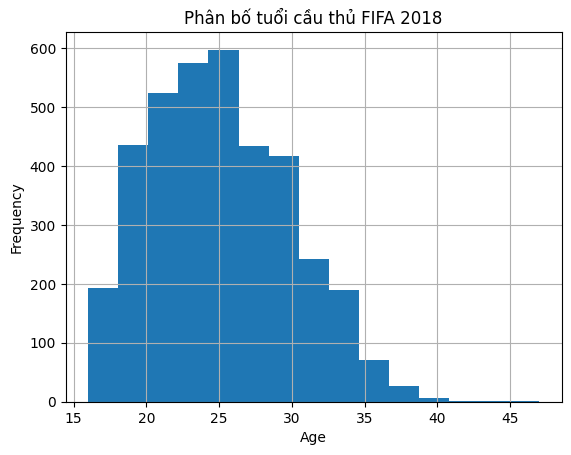

In [44]:
if DATA_DIR is not None:
    import matplotlib.pyplot as plt

    age_pd = (
        fifa_df
        .select("Age")
        .where("Age IS NOT NULL")
        .sample(False, 0.2, seed=42)
        .toPandas()
    )

    age_pd["Age"].hist(bins=15)
    plt.title("Phân bố tuổi cầu thủ FIFA 2018")
    plt.xlabel("Age")
    plt.ylabel("Frequency")
    plt.show()

## 11.1. Mật độ tuổi cầu thủ Germany

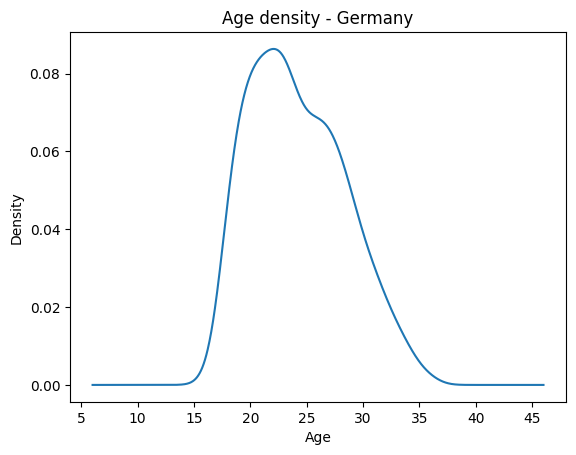

In [45]:
if DATA_DIR is not None:
    import matplotlib.pyplot as plt

    germany_age_pd = (
        fifa_df
        .filter("Nationality = 'Germany'")
        .select("Age")
        .toPandas()
    )

    germany_age_pd["Age"].plot(kind="density")
    plt.title("Age density - Germany")
    plt.xlabel("Age")
    plt.show()

<a id="mllib"></a>
# 12. Tổng quan Spark MLlib

Các nhóm bài toán trong slide:

- Collaborative Filtering
- Classification
- Clustering

Slide dùng một số API `pyspark.mllib` kiểu RDD.  
Phần thực hành dưới đây dùng chủ yếu **`pyspark.ml` DataFrame API** để phù hợp với PySpark hiện đại.

<a id="als"></a>
# 13. Collaborative Filtering với ALS

ALS = Alternating Least Squares.

Bộ dữ liệu `Movie ratings.csv` có cấu trúc:

```text
userId, movieId, rating, timestamp
```

In [46]:
if DATA_DIR is not None:
    from pyspark.sql.types import StructType, StructField, IntegerType, FloatType, LongType

    ratings_schema = StructType([
        StructField("userId", IntegerType(), True),
        StructField("movieId", IntegerType(), True),
        StructField("rating", FloatType(), True),
        StructField("timestamp", LongType(), True),
    ])

    ratings_df = spark.read.csv(
        str(DATA_DIR / "Movie ratings.csv"),
        header=False,
        schema=ratings_schema
    )

    ratings_df.show(5)
    print("Số rating:", ratings_df.count())

+------+-------+------+----------+
|userId|movieId|rating| timestamp|
+------+-------+------+----------+
|     1|     31|   2.5|1260759144|
|     1|   1029|   3.0|1260759179|
|     1|   1061|   3.0|1260759182|
|     1|   1129|   2.0|1260759185|
|     1|   1172|   4.0|1260759205|
+------+-------+------+----------+
only showing top 5 rows
Số rating: 100004


## 13.1. Chia train/test

In [47]:
if DATA_DIR is not None:
    train_df, test_df = ratings_df.randomSplit([0.8, 0.2], seed=42)

    print("Train:", train_df.count())
    print("Test :", test_df.count())

Train: 79905
Test : 20099


## 13.2. Huấn luyện ALS

In [48]:
if DATA_DIR is not None:
    from pyspark.ml.recommendation import ALS

    als = ALS(
        userCol="userId",
        itemCol="movieId",
        ratingCol="rating",
        rank=10,
        maxIter=10,
        regParam=0.1,
        coldStartStrategy="drop",
        nonnegative=True
    )

    als_model = als.fit(train_df)
    predictions = als_model.transform(test_df)

    predictions.select(
        "userId", "movieId", "rating", "prediction"
    ).show(10)

+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|   148|    185|   3.0| 3.0011418|
|   148|    364|   4.0| 4.1416683|
|   148|    596|   4.5| 3.9568043|
|   148|   1028|   5.0|  4.155044|
|   148|   1136|   4.5|  4.529189|
|   148|   1172|   5.0| 4.5098286|
|   148|   1208|   5.0| 4.2928886|
|   148|   1247|   4.0| 4.0840344|
|   148|   1517|   4.5| 3.4972937|
|   148|   1625|   4.0| 3.6907618|
+------+-------+------+----------+
only showing top 10 rows


## 13.3. Đánh giá MSE và RMSE

In [49]:
if DATA_DIR is not None:
    from pyspark.ml.evaluation import RegressionEvaluator

    rmse_eval = RegressionEvaluator(
        metricName="rmse",
        labelCol="rating",
        predictionCol="prediction"
    )

    mse_eval = RegressionEvaluator(
        metricName="mse",
        labelCol="rating",
        predictionCol="prediction"
    )

    print("RMSE =", rmse_eval.evaluate(predictions))
    print("MSE  =", mse_eval.evaluate(predictions))

RMSE = 0.9095716588113514
MSE  = 0.8273206025128335


## 13.4. Sinh khuyến nghị

In [50]:
if DATA_DIR is not None:
    recommendations = als_model.recommendForAllUsers(5)
    recommendations.show(5, truncate=False)

+------+---------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                    |
+------+---------------------------------------------------------------------------------------------------+
|1     |[{1192, 3.8576229}, {2275, 3.857607}, {72224, 3.76695}, {1361, 3.7196023}, {72641, 3.6756692}]     |
|2     |[{1192, 5.0105076}, {26084, 4.882744}, {83411, 4.819837}, {83359, 4.819837}, {83318, 4.819837}]    |
|3     |[{83411, 4.7065845}, {83359, 4.7065845}, {83318, 4.7065845}, {67504, 4.7065845}, {92494, 4.604339}]|
|4     |[{83411, 6.550705}, {83359, 6.550705}, {83318, 6.550705}, {67504, 6.550705}, {80599, 5.895634}]    |
|5     |[{65188, 5.5255384}, {89904, 5.410165}, {42418, 5.1438913}, {68099, 4.891819}, {1948, 4.8446865}]  |
+------+---------------------------------------------------------------------------------------------------+
only showing top 5 

<a id="classification"></a>
# 14. Classification với Logistic Regression

[MỞ RỘNG] Dùng hai file `spam.txt` và `ham.txt` để xây dựng bài toán phân loại tin nhắn.

Pipeline:

```text
text
 → Tokenizer
 → HashingTF
 → IDF
 → LogisticRegression
```

In [51]:
if DATA_DIR is not None:
    from pyspark.sql import Row

    spam_rdd = sc.textFile(str(DATA_DIR / "spam.txt")).map(
        lambda x: Row(label=1.0, text=x)
    )
    ham_rdd = sc.textFile(str(DATA_DIR / "ham.txt")).map(
        lambda x: Row(label=0.0, text=x)
    )

    messages_df = spark.createDataFrame(spam_rdd.union(ham_rdd))

    messages_df.show(5, truncate=False)
    print("Số tin nhắn:", messages_df.count())

+-----+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|text                                                                                                                                                             |
+-----+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1.0  |You have 1 new message. Please call 08712400200.                                                                                                                 |
|1.0  |Urgent! Please call 09061743811 from landline. Your ABTA complimentary 4* Tenerife Holiday or Â£5000 cash await collection SAE T&Cs Box 326 CW25WX 150ppm        |
|1.0  |Dear 0776xxxxxxx U've been invited to XCHAT. This is our final attempt to contact u! Txt CHAT to 86688 150p/MsgrcvdHG/Suite342/2Lands/Row/W1J6H

In [52]:
if DATA_DIR is not None:
    from pyspark.ml import Pipeline
    from pyspark.ml.feature import Tokenizer, HashingTF, IDF
    from pyspark.ml.classification import LogisticRegression

    tokenizer = Tokenizer(inputCol="text", outputCol="words")
    hashing_tf = HashingTF(
        inputCol="words",
        outputCol="rawFeatures",
        numFeatures=2000
    )
    idf = IDF(inputCol="rawFeatures", outputCol="features")
    lr = LogisticRegression(
        featuresCol="features",
        labelCol="label",
        maxIter=20
    )

    pipeline = Pipeline(stages=[tokenizer, hashing_tf, idf, lr])

    msg_train, msg_test = messages_df.randomSplit([0.8, 0.2], seed=42)
    spam_model = pipeline.fit(msg_train)
    spam_pred = spam_model.transform(msg_test)

    spam_pred.select(
        "text", "label", "prediction", "probability"
    ).show(10, truncate=70)

+----------------------------------------------------------------------+-----+----------+-------------------------------------------+
|                                                                  text|label|prediction|                                probability|
+----------------------------------------------------------------------+-----+----------+-------------------------------------------+
|+123 Congratulations - in this week's competition draw u have won t...|  1.0|       1.0|                [5.220025377537003E-19,1.0]|
|07732584351 - Rodger Burns - MSG = We tried to call you re your rep...|  1.0|       1.0|                [7.027802946433561E-25,1.0]|
|1000's of girls many local 2 u who r virgins 2 this & r ready 2 4fi...|  1.0|       1.0| [2.1119382530522851E-7,0.9999997888061747]|
|44 7732584351, Do you want a New Nokia 3510i colour phone Delivered...|  1.0|       1.0|   [3.996219338275807E-14,0.99999999999996]|
|500 New Mobiles from 2004, MUST GO! Txt: NOKIA to No: 89545 &

## 14.1. Đánh giá mô hình

In [53]:
if DATA_DIR is not None:
    from pyspark.ml.evaluation import BinaryClassificationEvaluator
    from pyspark.ml.evaluation import MulticlassClassificationEvaluator

    auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    ).evaluate(spam_pred)

    accuracy = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    ).evaluate(spam_pred)

    print("AUC      =", auc)
    print("Accuracy =", accuracy)

AUC      = 0.964938331710485
Accuracy = 0.9545454545454546


<a id="kmeans"></a>
# 15. Clustering với K-Means

Bộ dữ liệu `5000_points.txt` gồm các điểm hai chiều.

Ta sẽ:

1. đọc dữ liệu;
2. tạo vector đặc trưng;
3. huấn luyện K-Means;
4. xem tâm cụm;
5. đánh giá bằng Silhouette;
6. trực quan hóa cụm.

In [54]:
if DATA_DIR is not None:
    from pyspark.sql import functions as F

    raw_points = spark.read.text(str(DATA_DIR / "5000_points.txt"))

    points_df = raw_points.select(
        F.split(F.col("value"), "\t")[0].cast("double").alias("x"),
        F.split(F.col("value"), "\t")[1].cast("double").alias("y")
    )

    points_df.show(5)
    print("Số điểm:", points_df.count())

+--------+--------+
|       x|       y|
+--------+--------+
|664159.0|550946.0|
|665845.0|557965.0|
|597173.0|575538.0|
|618600.0|551446.0|
|635690.0|608046.0|
+--------+--------+
only showing top 5 rows
Số điểm: 5000


In [55]:
if DATA_DIR is not None:
    from pyspark.ml.feature import VectorAssembler
    from pyspark.ml.clustering import KMeans

    assembler = VectorAssembler(
        inputCols=["x", "y"],
        outputCol="features"
    )

    vector_df = assembler.transform(points_df)

    kmeans = KMeans(
        k=4,
        seed=42,
        featuresCol="features",
        predictionCol="cluster"
    )

    kmeans_model = kmeans.fit(vector_df)
    clustered_df = kmeans_model.transform(vector_df)

    clustered_df.select("x", "y", "cluster").show(10)

+--------+--------+-------+
|       x|       y|cluster|
+--------+--------+-------+
|664159.0|550946.0|      1|
|665845.0|557965.0|      1|
|597173.0|575538.0|      1|
|618600.0|551446.0|      1|
|635690.0|608046.0|      1|
|588100.0|557588.0|      1|
|582015.0|546191.0|      1|
|604678.0|574577.0|      1|
|572029.0|518313.0|      1|
|604737.0|574591.0|      1|
+--------+--------+-------+
only showing top 10 rows


## 15.1. Tâm cụm

In [56]:
if DATA_DIR is not None:
    centers = kmeans_model.clusterCenters()

    for i, center in enumerate(centers):
        print(f"Cluster {i}: {center}")

Cluster 0: [348842.67180617 273754.1835536 ]
Cluster 1: [741567.88402458 684713.76267281]
Cluster 2: [280979.19126506 687372.9939759 ]
Cluster 3: [754863.40575397 294012.5109127 ]


## 15.2. Silhouette Score

In [57]:
if DATA_DIR is not None:
    from pyspark.ml.evaluation import ClusteringEvaluator

    evaluator = ClusteringEvaluator(
        predictionCol="cluster",
        featuresCol="features",
        metricName="silhouette",
        distanceMeasure="squaredEuclidean"
    )

    print("Silhouette =", evaluator.evaluate(clustered_df))

Silhouette = 0.614662491276157


## 15.3. Trực quan hóa các cụm

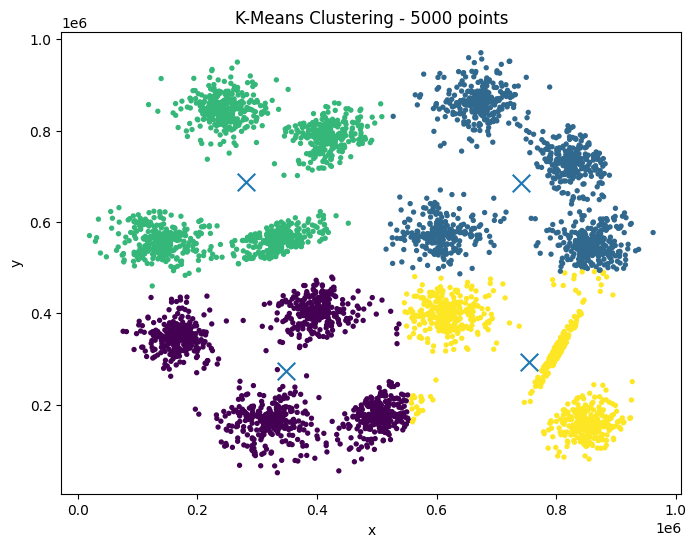

In [58]:
if DATA_DIR is not None:
    import pandas as pd
    import matplotlib.pyplot as plt

    cluster_pd = clustered_df.select("x", "y", "cluster").toPandas()
    centers_pd = pd.DataFrame(centers, columns=["x", "y"])

    plt.figure(figsize=(8, 6))
    plt.scatter(
        cluster_pd["x"],
        cluster_pd["y"],
        c=cluster_pd["cluster"],
        s=8
    )
    plt.scatter(
        centers_pd["x"],
        centers_pd["y"],
        marker="x",
        s=160
    )
    plt.title("K-Means Clustering - 5000 points")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

<a id="exercise"></a>
# 16. Bài tập tự luyện

## Bài 1 - RDD

Tạo RDD các số từ 1 đến 100:

1. lọc số chẵn;
2. bình phương;
3. tính tổng các bình phương;
4. xem số partition.

## Bài 2 - Pair RDD

Với dữ liệu:

```python
transactions = [
    ("A", 100),
    ("B", 200),
    ("A", 50),
    ("C", 400),
    ("B", 100)
]
```

Yêu cầu:

1. tổng giá trị theo khách hàng;
2. sắp xếp giảm dần;
3. tìm khách hàng lớn nhất.

## Bài 3 - Word Count

1. Top 30 từ trong Shakespeare.
2. Bỏ stop words.
3. Chỉ giữ từ dài từ 5 ký tự.
4. So sánh trước/sau lọc.

## Bài 4 - FIFA DataFrame

1. Tìm 10 cầu thủ trẻ nhất.
2. Tuổi trung bình theo quốc gia.
3. Top 10 quốc gia có Overall trung bình cao nhất.
4. Lọc cầu thủ có Overall >= 85.
5. Đếm cầu thủ theo vị trí.

## Bài 5 - Spark SQL

1. Cầu thủ Germany có Overall >= 80.
2. AVG(Age) theo quốc gia.
3. CLB có nhiều cầu thủ nhất.
4. Top 10 `Potential - Overall`.

## Bài 6 - Machine Learning

1. Thay đổi `rank`, `maxIter`, `regParam` của ALS.
2. So sánh RMSE.
3. Thử K-Means với `k = 2..6`.
4. So sánh Silhouette.

## Gợi ý lời giải Bài 1

In [59]:
exercise_rdd = sc.parallelize(range(1, 101))

even_squared = (
    exercise_rdd
    .filter(lambda x: x % 2 == 0)
    .map(lambda x: x ** 2)
)

print("10 phần tử đầu:", even_squared.take(10))
print("Tổng:", even_squared.reduce(lambda x, y: x + y))
print("Partitions:", even_squared.getNumPartitions())

10 phần tử đầu: [4, 16, 36, 64, 100, 144, 196, 256, 324, 400]
Tổng: 171700
Partitions: 2


## Gợi ý lời giải Bài 2

In [60]:
transactions = sc.parallelize([
    ("A", 100),
    ("B", 200),
    ("A", 50),
    ("C", 400),
    ("B", 100)
])

totals = transactions.reduceByKey(lambda x, y: x + y)

ranking = (
    totals
    .map(lambda x: (x[1], x[0]))
    .sortByKey(ascending=False)
)

print("Tổng:", totals.collect())
print("Xếp hạng:", ranking.collect())
print("Lớn nhất:", ranking.first())

Tổng: [('A', 150), ('B', 300), ('C', 400)]
Xếp hạng: [(400, 'C'), (300, 'B'), (150, 'A')]
Lớn nhất: (400, 'C')


<a id="summary"></a>
# 17. Tổng kết

Trình tự kiến thức của notebook:

```text
Big Data
   ↓
Apache Spark
   ↓
SparkSession / SparkContext
   ↓
RDD
   ↓
Transformations & Actions
   ↓
Pair RDD
   ↓
DataFrame
   ↓
Spark SQL
   ↓
Visualization
   ↓
Spark ML
      ├── ALS
      ├── Logistic Regression
      └── K-Means
```

## Ghi nhớ

1. Spark hỗ trợ xử lý phân tán và song song.
2. RDD transformations có lazy evaluation.
3. Hạn chế `collect()` trên dữ liệu lớn.
4. DataFrame phù hợp với dữ liệu có cấu trúc.
5. Spark SQL và DataFrame API có thể kết hợp.
6. Chỉ dùng `toPandas()` sau khi giảm kích thước dữ liệu.
7. Với project mới, nên ưu tiên `pyspark.ml`.

In [61]:
# Chỉ chạy khi đã hoàn thành toàn bộ notebook:
spark.stop()

# Kết thúc